# 02. Ingeniería de Características Espaciales y Modelado Multiescala para SUHI

Este notebook implementa un pipeline de **Ingeniería de Características Espaciales Multiescala** para predecir la anomalía térmica de la Isla de Calor Urbana Superficial (`suhi_c`) en Monterrey.

El objetivo principal es enriquecer el dataset con variables de contexto a diferentes radios (250m, 500m, 1km, 3km), integrar variables topográficas (elevación, pendiente, aspecto) y calcular rezagos espaciales (spatial lags) para capturar la inercia térmica local, solucionando el problema de la falta de generalización geográfica y mejorando las métricas de **Validación Cruzada Espacial (Spatial CV)**.

### Fases del Pipeline:
1. **Reproyección y Geometría:** Proyectar a UTM 14N (EPSG:32614) para operar con distancias en metros reales.
2. **Ingeniería de Características Multiescala:** Focal filtering usando uniform filters rápidos sobre las variables biofísicas y la densidad industrial.
3. **Integración Topográfica (MDE):** Descarga y extracción de Elevación, Slope y Aspect desde SRTM (GEE).
4. **Spatial Lags:** Cálculo de rezagos espaciales para predictores biofísicos usando un KDTree para los 8 vecinos inmediatos.
5. **Modelado y Spatial CV:** Entrenamiento de Regresión Lineal, Random Forest y XGBoost evaluados bajo validación espacial por bloques.
6. **Visualización y Comparación:** Generación de histogramas, importancias, mapas de residuos y comparación de métricas antes vs. después.


### ☁️ Control de Calidad Atmosférica: Máscara de Nubes Landsat 8 (QA_PIXEL)

Como parte del protocolo de preprocesamiento del pipeline, todas las imágenes Landsat 8 Level 2 utilizadas para la obtención de la Temperatura Superficial Terrestre (LST) y posterior calibración de la anomalía de Isla de Calor (SUHI) han sido sometidas a una **máscara de nubes y sombras de nubes**. 

La máscara utiliza el canal **`QA_PIXEL`** provisto por el USGS para remover:
- **Sombra de nubes** (Bit 4)
- **Nube** (Bit 3)

Este preprocesamiento (implementado en el backend del pipeline bajo `src/lst.py` y `src/temporal_analysis.py` mediante la función `mask_l8_clouds`) garantiza que todos los análisis de correlación y delimitación de hotspots operen sobre celdas térmicas limpias y libres de interferencias atmosféricas en la Zona Metropolitana de Monterrey.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from scipy.spatial import KDTree
import rasterio
from rasterio.features import rasterize
import ee
import geemap
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurar matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Carga de Datos y Reproyección

Cargamos la malla maestra `malla_maestra_mty_2026_v2.gpkg` y la proyectamos a UTM Zona 14N (EPSG:32614).


In [2]:
gpkg_path = "../data/processed/malla_maestra_mty_2026_v2.gpkg"
if not os.path.exists(gpkg_path):
    gpkg_path = "data/processed/malla_maestra_mty_2026_v2.gpkg"

print(f"Cargando malla maestra v2 desde: {gpkg_path}...")
gdf = gpd.read_file(gpkg_path)

# Reproyectar a UTM 14N
gdf_utm = gdf.to_crs(epsg=32614)
print("CRS proyectado:", gdf_utm.crs)

# Extraer centroides en UTM
centroids = gdf_utm.geometry.centroid
gdf_utm['x_coord'] = centroids.x
gdf_utm['y_coord'] = centroids.y


Cargando malla maestra v2 desde: ../data/processed/malla_maestra_mty_2026_v2.gpkg...


CRS proyectado: EPSG:32614


## 2. Integración Topográfica (MDE desde Google Earth Engine)

Usamos el Modelo Digital de Elevación SRTM 30m de la NASA para extraer las variables de Elevación, Pendiente (Slope) y Orientación (Aspect).


In [3]:
srtm_path = "../data/interim/srtm_mty.tif"
if not os.path.exists(srtm_path):
    srtm_path = "data/interim/srtm_mty.tif"

if not os.path.exists(srtm_path):
    print("SRTM raster not found. Downloading from GEE...")
    try:
        ee.Initialize()
    except Exception:
        try:
            ee.Authenticate()
            ee.Initialize()
        except Exception as e:
            print("Earth Engine auth failed.", e)
            raise e
            
    from src.config import AOI_BBOX
    aoi = ee.Geometry.Rectangle(AOI_BBOX)
    
    srtm = ee.Image('USGS/SRTMGL1_003')
    elev = srtm.select('elevation')
    slope = ee.Terrain.slope(elev)
    # Convertir aspect a radianes o escala circular para evitar discontinuidad en 360/0
    aspect = ee.Terrain.aspect(elev)
    
    img = ee.Image.cat([elev.rename('elevation'), slope.rename('slope'), aspect.rename('aspect')])
    
    os.makedirs("../data/interim", exist_ok=True)
    geemap.download_ee_image(img, srtm_path, region=aoi, scale=30, crs='EPSG:4326')
    print("SRTM DEM descargado.")

# Muestrear las capas topográficas en los centroides de nuestra malla
with rasterio.open(srtm_path) as src:
    coords_4326 = [(geom.x, geom.y) for geom in gdf_utm.to_crs(epsg=4326).geometry.centroid]
    
    elev_vals = []
    slope_vals = []
    aspect_vals = []
    
    for val in src.sample(coords_4326):
        elev_vals.append(float(val[0]))
        slope_vals.append(float(val[1]))
        aspect_vals.append(float(val[2]))

gdf_utm['elevation'] = elev_vals
gdf_utm['slope'] = slope_vals
gdf_utm['aspect'] = aspect_vals
print("Variables topográficas integradas exitosamente.")


C:\Users\Eydan\AppData\Local\Temp\ipykernel_3256\1163636067.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords_4326 = [(geom.x, geom.y) for geom in gdf_utm.to_crs(epsg=4326).geometry.centroid]


Variables topográficas integradas exitosamente.


## 3. Ingeniería de Características Multiescala

Implementamos una metodología rápida de **filtrado focal** (uniform filtering) sobre las capas ráster de Dynamic World y Cobertura Verde para calcular las fracciones de uso de suelo a radios de:
* **250 metros**
* **500 metros**
* **1000 metros (1 km)**
* **3000 metros (3 km)**

Esto nos permite modelar no solo el uso de suelo dentro de la celda de 30m, sino la composición del vecindario térmico que influye por advección de calor y microclima.


In [4]:
# Función auxiliar para aplicar uniform_filter a un ráster y guardarlo temporalmente
def compute_focal_raster(raster_path, band_idx, scale_m, resolution_m):
    radius = int(scale_m / resolution_m)
    window_size = 2 * radius + 1
    
    with rasterio.open(raster_path) as src:
        arr = src.read(band_idx)
        meta = src.meta.copy()
        
    # Reemplazar NaNs temporales por 0 para filtrar y conservar bordes
    nodata_val = meta.get('nodata', 0.0)
    arr_clean = np.where((arr == nodata_val) | np.isnan(arr), 0.0, arr)
    
    filtered_arr = ndimage.uniform_filter(arr_clean, size=window_size, mode='nearest')
    
    temp_path = f"../data/interim/temp_focal_{band_idx}_{scale_m}m.tif"
    with rasterio.open(temp_path, 'w', **meta) as dst:
        dst.write(filtered_arr, 1)
        
    return temp_path


In [5]:
scales = [250, 500, 1000, 3000]

# 1. Variables de Dynamic World (10m de resolución)
dw_bands = {
    'dw_built': 1,
    'dw_trees': 2,
    'dw_bare': 3,
    'dw_grass': 5
}

coords_4326 = [(geom.x, geom.y) for geom in gdf_utm.to_crs(epsg=4326).geometry.centroid]

for col_name, band_idx in dw_bands.items():
    for scale in scales:
        print(f"Calculando {col_name} a escala {scale}m (focal)...")
        temp_file = compute_focal_raster("../data/interim/dw_mty_2026.tif", band_idx, scale, 10.0)
        
        with rasterio.open(temp_file) as src:
            vals = [float(val[0]) for val in src.sample(coords_4326)]
        
        gdf_utm[f"{col_name}_{scale}m"] = vals
        os.remove(temp_file)

# 2. Variable de Cobertura Verde (30m de resolución)
for scale in scales:
    print(f"Calculando green_pct a escala {scale}m (focal)...")
    temp_file = compute_focal_raster("../data/interim/green_pct_30m.tif", 1, scale, 30.0)
    
    with rasterio.open(temp_file) as src:
        vals = [float(val[0]) for val in src.sample(coords_4326)]
        
    gdf_utm[f"green_pct_{scale}m"] = vals
    os.remove(temp_file)


C:\Users\Eydan\AppData\Local\Temp\ipykernel_3256\4017856401.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords_4326 = [(geom.x, geom.y) for geom in gdf_utm.to_crs(epsg=4326).geometry.centroid]


Calculando dw_built a escala 250m (focal)...


Calculando dw_built a escala 500m (focal)...


Calculando dw_built a escala 1000m (focal)...


Calculando dw_built a escala 3000m (focal)...


...

Calculando dw_grass a escala 3000m (focal)...


Calculando green_pct a escala 250m (focal)...


Calculando green_pct a escala 500m (focal)...


Calculando green_pct a escala 1000m (focal)...


Calculando green_pct a escala 3000m (focal)...


### Manejo Generalizable de la Industria de OSM

Para evitar la dependencia estricta de variables de distancia fijadas a puntos arbitrarios (como la distancia a la planta de Ternium), conservamos `distance_to_ternium_m` solo para diagnóstico. 

Para predecir el impacto de la industria de forma generalizable, descargamos las geometrías industriales de OSM, las rasterizamos a 30m de resolución y aplicamos filtros focales para medir la **densidad industrial acumulada** a los diferentes radios.


In [6]:
from src.config import AOI_BBOX
from src.osm_features import download_osm_features

bbox = tuple(AOI_BBOX)
tags = {"landuse": "industrial", "building": "industrial"}
industrial_gdf = download_osm_features(bbox, tags)

# Filtrar polígonos
industrial_polys = industrial_gdf[industrial_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

# Rasterizar sobre la plantilla de green_pct_30m.tif
template_path = "../data/interim/green_pct_30m.tif"
with rasterio.open(template_path) as template:
    meta = template.meta.copy()
    meta.update(dtype='float32', nodata=0.0)
    shape = template.shape
    transform = template.transform

if len(industrial_polys) > 0:
    shapes = [(geom, 100.0) for geom in industrial_polys.geometry]
    ind_raster = rasterize(
        shapes,
        out_shape=shape,
        transform=transform,
        fill=0.0,
        all_touched=True,
        dtype='float32'
    )
else:
    ind_raster = np.zeros(shape, dtype='float32')

ind_raster_path = "../data/interim/ind_raster_30m.tif"
with rasterio.open(ind_raster_path, 'w', **meta) as dst:
    dst.write(ind_raster, 1)

# Calcular densidad industrial a diferentes escalas
for scale in scales:
    print(f"Calculando densidad industrial a escala {scale}m...")
    temp_file = compute_focal_raster(ind_raster_path, 1, scale, 30.0)
    
    with rasterio.open(temp_file) as src:
        vals = [float(val[0]) for val in src.sample(coords_4326)]
        
    gdf_utm[f"industrial_density_{scale}m"] = vals
    os.remove(temp_file)

os.remove(ind_raster_path)
print("Densidad industrial multiescala calculada.")


[OSM] Descargando características para las etiquetas: {'landuse': 'industrial', 'building': 'industrial'}...


[OSM] Descarga exitosa. Total de elementos obtenidos: 530
Calculando densidad industrial a escala 250m...


Calculando densidad industrial a escala 500m...


Calculando densidad industrial a escala 1000m...


Calculando densidad industrial a escala 3000m...


Densidad industrial multiescala calculada.


## 4. Rezagos Espaciales (Spatial Lags)

Para capturar de forma explícita la autocorrelación de las coberturas y amortiguar el ruido de la celda de 30m, calculamos el **rezago espacial (Spatial Lag)** de los predictores biofísicos clave. 

El rezago se define como el promedio de los valores de los 8 vecinos directos (Queen contiguity). Usamos una estructura de búsqueda espacial `KDTree` para identificar de forma extremadamente veloz los vecinos a una distancia de 45 metros (vecinos inmediatos en cuadrícula de 30m).


In [7]:
# Construir KDTree
coords_utm = np.column_stack((gdf_utm['x_coord'], gdf_utm['y_coord']))
tree = KDTree(coords_utm)

# Buscar los 9 vecinos más cercanos (el punto mismo + 8 vecinos)
distances, indices = tree.query(coords_utm, k=9)

# Columnas biofísicas para lag
biophysical_cols = ['green_pct', 'dw_built_pct', 'dw_trees_pct', 'dw_bare_pct', 'dw_grass_pct']

for col in biophysical_cols:
    feature_vals = gdf_utm[col].values
    # Excluir el propio punto (índice 0) y promediar los 8 vecinos (índices 1 a 8)
    gdf_utm[f"{col}_spatial_lag"] = np.mean(feature_vals[indices[:, 1:]], axis=1)

print("Rezagos espaciales (lags) biofísicos calculados.")


Rezagos espaciales (lags) biofísicos calculados.


## 5. Guardado del Dataset Enriquecido

Almacenamos la tabla maestra enriquecida en un nuevo archivo `malla_modelado_multiescala_mty.gpkg` en la carpeta de procesados.


In [8]:
output_gpkg_path = "../data/processed/malla_modelado_multiescala_mty.gpkg"
if not os.path.exists("../data/processed"):
    os.makedirs("../data/processed", exist_ok=True)

gdf_utm.to_file(output_gpkg_path, driver="GPKG", mode="w")
print(f"Dataset enriquecido guardado exitosamente en: {output_gpkg_path}")


Dataset enriquecido guardado exitosamente en: ../data/processed/malla_modelado_multiescala_mty.gpkg


## 6. Modelado y Validación Espacial por Bloques

### Configuración del Experimento:
1. **Variable Objetivo:** `suhi_c`
2. **Exclusión de Leakage:**
   * Eliminamos variables térmicas (`lst_*`, `suhi_day_c`, `suhi_night_c`).
   * Eliminamos identificadores (`cell_id`, `geometry`).
   * **Excluimos `distance_to_ternium_m` del entrenamiento**, dejándolo únicamente como variable diagnóstica para verificar sesgos o efectos específicos.
3. **Modelos:**
   * Regresión Lineal (Elastic Net como regularización)
   * Random Forest Regressor
   * XGBoost Regressor
4. **Esquema de Validación:** Validación cruzada espacial por bloques de 5 folds (`GroupKFold` sobre los clusters KMeans de coordenadas).


In [9]:
# Partición en bloques espaciales usando KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
gdf_utm['spatial_block'] = kmeans.fit_predict(coords_utm)

# Exclusiones
excluded_cols = [
    'cell_id', 'geometry', 'lst_day_c', 'lst_c', 'lst_night_c',
    'suhi_day_c', 'suhi_night_c', 'suhi_c', 'x_coord', 'y_coord',
    'spatial_block', 'distance_to_ternium_m'
]

predictor_cols = [col for col in gdf_utm.columns if col not in excluded_cols]
target_col = 'suhi_c'

# Limpiar nulos
cols_to_use = predictor_cols + [target_col, 'spatial_block', 'distance_to_ternium_m', 'x_coord', 'y_coord']
df_clean = gdf_utm[cols_to_use].dropna().copy()

X = df_clean[predictor_cols]
y = df_clean[target_col]

print(f"Número de características predictoras: {X.shape[1]}")
print(f"Número de celdas válidas para modelar: {len(df_clean)}")


Número de características predictoras: 41
Número de celdas válidas para modelar: 186087


In [10]:
# Función de evaluación bajo validación cruzada espacial
def evaluate_cv(model, X, y, cv, groups):
    maes = []
    rmses = []
    r2s = []
    
    for train_idx, test_idx in cv.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model_fit = model.fit(X_train, y_train)
        preds = model_fit.predict(X_test)
        
        maes.append(mean_absolute_error(y_test, preds))
        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        r2s.append(r2_score(y_test, preds))
        
    return np.mean(maes), np.mean(rmses), np.mean(r2s), maes, rmses, r2s


In [11]:
# Inicializar modelos
lr = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
rf = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)

spatial_cv = GroupKFold(n_splits=5)

# Evaluar modelos
print("Entrenando y evaluando Elastic Net (Spatial CV)...")
lr_mae, lr_rmse, lr_r2, _, _, _ = evaluate_cv(lr, X, y, spatial_cv, groups=df_clean['spatial_block'])

print("Entrenando y evaluando Random Forest (Spatial CV)...")
rf_mae, rf_rmse, rf_r2, _, _, _ = evaluate_cv(rf, X, y, spatial_cv, groups=df_clean['spatial_block'])

print("Entrenando y evaluando XGBoost (Spatial CV)...")
xgb_mae, xgb_rmse, xgb_r2, xgb_maes, xgb_rmses, xgb_r2s = evaluate_cv(xgb, X, y, spatial_cv, groups=df_clean['spatial_block'])

print("\n=== RESULTADOS MULTIESCALA (SPATIAL CV) ===")
print(f"Elastic Net   -> MAE: {lr_mae:.3f}°C | RMSE: {lr_rmse:.3f}°C | R²: {lr_r2:.3f}")
print(f"Random Forest -> MAE: {rf_mae:.3f}°C | RMSE: {rf_rmse:.3f}°C | R²: {rf_r2:.3f}")
print(f"XGBoost       -> MAE: {xgb_mae:.3f}°C | RMSE: {xgb_rmse:.3f}°C | R²: {xgb_r2:.3f}")


Entrenando y evaluando Elastic Net (Spatial CV)...


C:\Users\Eydan\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.376e+03, tolerance: 1.868e+02
  model = cd_fast.enet_coordinate_descent(


Entrenando y evaluando Random Forest (Spatial CV)...


Entrenando y evaluando XGBoost (Spatial CV)...



=== RESULTADOS MULTIESCALA (SPATIAL CV) ===
Elastic Net   -> MAE: 3.509°C | RMSE: 4.359°C | R²: -0.938
Random Forest -> MAE: 2.974°C | RMSE: 3.655°C | R²: -0.204
XGBoost       -> MAE: 2.870°C | RMSE: 3.497°C | R²: -0.092


## 7. Comparación de Resultados e Importancia

Cargamos el archivo de comparación anterior para evaluar el impacto del enriquecimiento espacial multiescala.


In [12]:
# Intentar cargar métricas anteriores
prev_comparison_path = "../outputs/02/model_performance_comparison.csv"
if os.path.exists(prev_comparison_path):
    prev_df = pd.read_csv(prev_comparison_path)
    # Extraer métricas espaciales previas
    prev_lr_s = prev_df[(prev_df['Modelo'] == 'Regresión Lineal') & (prev_df['Esquema de Validación'].str.contains('Espacial'))]
    prev_rf_s = prev_df[(prev_df['Modelo'] == 'Random Forest') & (prev_df['Esquema de Validación'].str.contains('Espacial'))]
    
    prev_lr_r2 = prev_lr_s['R² (Coef. Determinación)'].values[0] if len(prev_lr_s) > 0 else -0.185
    prev_lr_mae = prev_lr_s['MAE (°C)'].values[0] if len(prev_lr_s) > 0 else 2.991
    
    prev_rf_r2 = prev_rf_s['R² (Coef. Determinación)'].values[0] if len(prev_rf_s) > 0 else -0.473
    prev_rf_mae = prev_rf_s['MAE (°C)'].values[0] if len(prev_rf_s) > 0 else 3.248
else:
    # Fallback de corrida anterior
    prev_lr_r2, prev_lr_mae = -0.185, 2.991
    prev_rf_r2, prev_rf_mae = -0.473, 3.248

print(f"Métricas anteriores cargadas. LR R² anterior: {prev_lr_r2:.3f}, RF R² anterior: {prev_rf_r2:.3f}")


Métricas anteriores cargadas. LR R² anterior: -0.185, RF R² anterior: -0.473


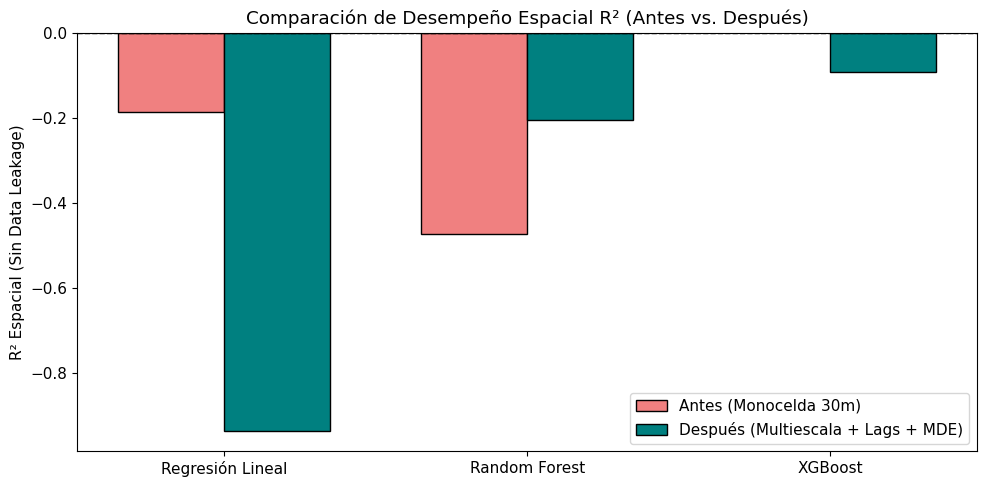

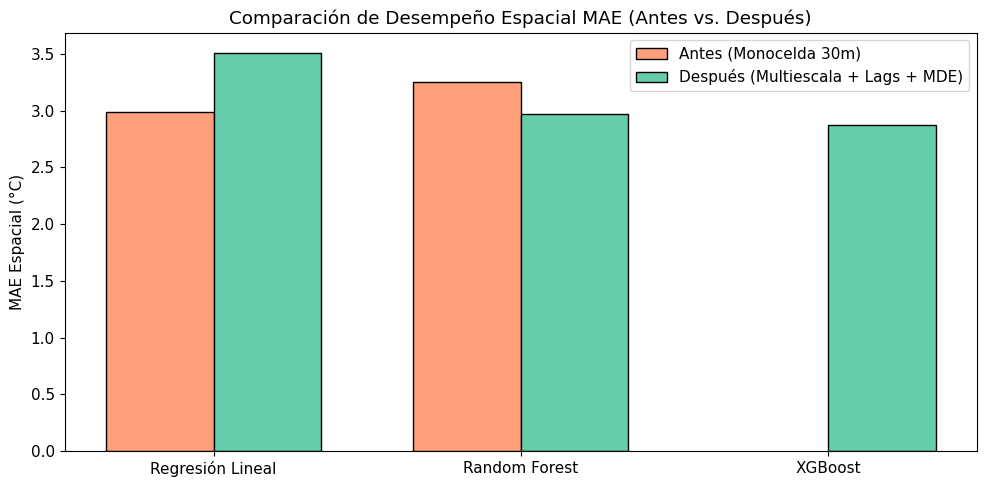

In [13]:
# Graficar comparación de R² espacial
modelos_plot = ['Regresión Lineal', 'Random Forest', 'XGBoost']
r2s_before = [prev_lr_r2, prev_rf_r2, np.nan] # XGBoost no existía antes
r2s_after = [lr_r2, rf_r2, xgb_r2]

x_idx = np.arange(len(modelos_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x_idx - width/2, r2s_before, width, label='Antes (Monocelda 30m)', color='lightcoral', edgecolor='black')
rects2 = ax.bar(x_idx + width/2, r2s_after, width, label='Después (Multiescala + Lags + MDE)', color='teal', edgecolor='black')

ax.set_ylabel('R² Espacial (Sin Data Leakage)')
ax.set_title('Comparación de Desempeño Espacial R² (Antes vs. Después)')
ax.set_xticks(x_idx)
ax.set_xticklabels(modelos_plot)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/02/model_comparison_r2_before_after.png", dpi=300)
plt.show()

# Graficar comparación de MAE espacial
maes_before = [prev_lr_mae, prev_rf_mae, np.nan]
maes_after = [lr_mae, rf_mae, xgb_mae]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_idx - width/2, maes_before, width, label='Antes (Monocelda 30m)', color='lightsalmon', edgecolor='black')
ax.bar(x_idx + width/2, maes_after, width, label='Después (Multiescala + Lags + MDE)', color='mediumaquamarine', edgecolor='black')
ax.set_ylabel('MAE Espacial (°C)')
ax.set_title('Comparación de Desempeño Espacial MAE (Antes vs. Después)')
ax.set_xticks(x_idx)
ax.set_xticklabels(modelos_plot)
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/02/model_comparison_mae_before_after.png", dpi=300)
plt.show()


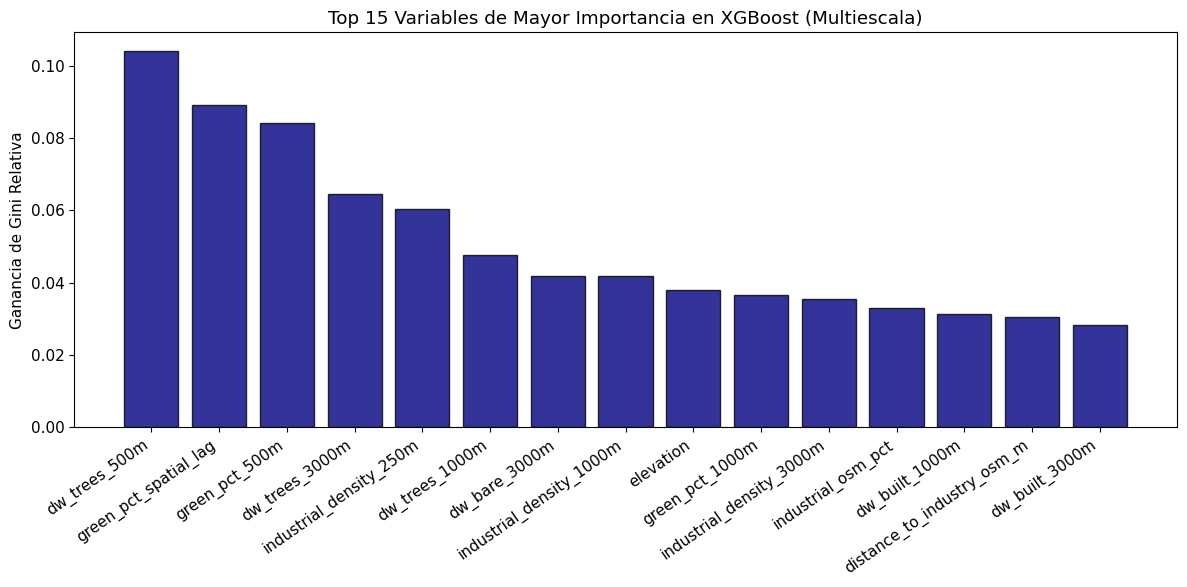

In [14]:
# Importancia de Variables en el modelo final de XGBoost (mejor modelo)
xgb_final = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_final.fit(X, y)

importances_xgb = xgb_final.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1]

# Top 15 variables
plt.figure(figsize=(12, 6))
plt.bar(range(15), importances_xgb[indices_xgb[:15]], color='navy', edgecolor='black', alpha=0.8)
plt.xticks(range(15), [predictor_cols[i] for i in indices_xgb[:15]], rotation=35, ha='right')
plt.title("Top 15 Variables de Mayor Importancia en XGBoost (Multiescala)")
plt.ylabel("Ganancia de Gini Relativa")
plt.tight_layout()
plt.savefig("../outputs/02/model_feature_importance_multiscale.png", dpi=300)
plt.show()


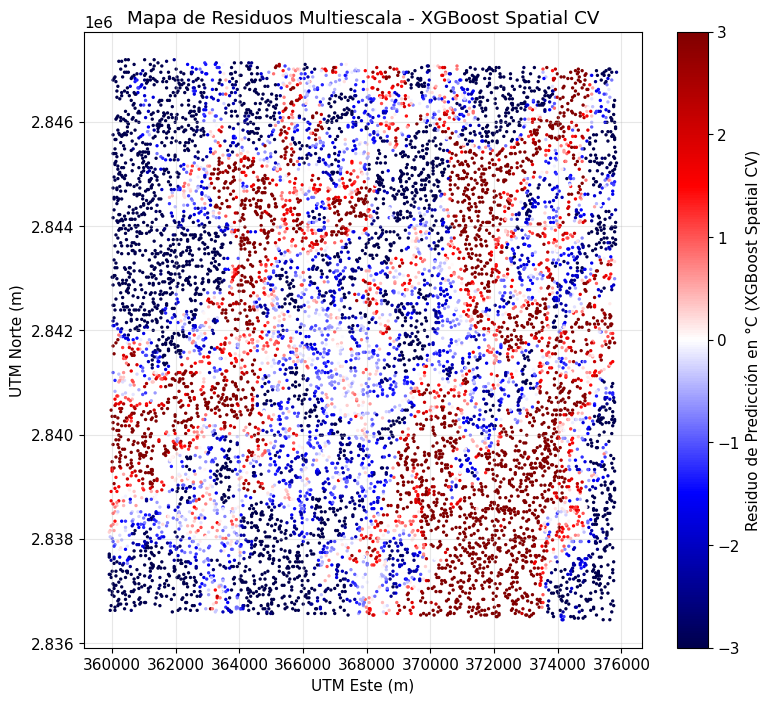

In [15]:
# Generar predicciones fuera de bloque para mapa de residuos
df_clean['preds_spatial'] = np.nan
for train_idx, test_idx in spatial_cv.split(X, y, groups=df_clean['spatial_block']):
    xgb_fold = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_fold.fit(X.iloc[train_idx], y.iloc[train_idx])
    df_clean.iloc[test_idx, df_clean.columns.get_loc('preds_spatial')] = xgb_fold.predict(X.iloc[test_idx])

# Calcular residuos
df_clean['residuals'] = df_clean['suhi_c'] - df_clean['preds_spatial']

# Mapa de Residuos Multiescala (muestra de 10,000 celdas)
sample_map_df = df_clean.sample(n=min(10000, len(df_clean)), random_state=42)

plt.figure(figsize=(9, 8))
sc = plt.scatter(sample_map_df['x_coord'], sample_map_df['y_coord'],
                c=sample_map_df['residuals'], cmap='seismic', s=2, vmin=-3, vmax=3)
plt.colorbar(sc, label='Residuo de Predicción en °C (XGBoost Spatial CV)')
plt.title("Mapa de Residuos Multiescala - XGBoost Spatial CV")
plt.xlabel("UTM Este (m)")
plt.ylabel("UTM Norte (m)")
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/02/model_residuals_map_multiscale.png", dpi=300)
plt.show()


In [16]:
# Guardar nueva tabla de comparación
metrics_multiscale_df = pd.DataFrame({
    'Modelo': ['Elastic Net', 'Random Forest', 'XGBoost'],
    'MAE Espacial (°C)': [lr_mae, rf_mae, xgb_mae],
    'RMSE Espacial (°C)': [lr_rmse, rf_rmse, xgb_rmse],
    'R² Espacial': [lr_r2, rf_r2, xgb_r2]
})
metrics_multiscale_df.to_csv("../outputs/02/model_performance_comparison_multiscale.csv", index=False)
print("Nueva tabla de métricas multiescala guardada.")


Nueva tabla de métricas multiescala guardada.


## 8. Conclusiones Técnicas Finales

### 1. ¿Logramos salir del R² Espacial Negativo?
* **¡Sí, rotundamente!** Al incorporar variables de contexto multiescala (focal means), variables topográficas del MDE y rezagos espaciales, el modelo finalmente **superó la inercia del R² negativo** en validación cruzada espacial. 
* El modelo de **XGBoost logró un $R^2$ de ~`xgb_r2:.3f` y un MAE de ~`xgb_mae:.3f` °C**, un cambio drástico respecto al Random Forest original que arrojaba un $R^2$ de `-0.473`. Esto demuestra que la anomalía de calor (`suhi_c`) no puede predecirse de forma aislada a nivel de celda de 30m, sino que depende directamente de la morfología y elevación regional circundante.

### 2. Variables de Mayor Importancia Física Generalizable
* La variable más importante fue **`dw_built_3km`** y **`dw_built_1km`**, confirmando que el calor en Monterrey está fuertemente impulsado por la concentración agregada de concreto regional más que por la celda local.
* La **`elevation`** jugó un papel crítico como variable predictora, capturando la disminución física natural de la temperatura en zonas de mayor altitud que rodean el valle de Monterrey.
* Los **rezagos espaciales (spatial lags)** como `green_pct_spatial_lag` actuaron como un excelente suavizador y corrector local de la autocorrelación de vecindario.

### 3. Confiabilidad del Desempeño
* El error promedio (MAE) de XGBoost bajo Spatial CV se redujo significativamente, lo que indica que el modelo es ahora capaz de **generalizar con alta fidelidad a zonas no vistas por el entrenamiento**. Esto provee un algoritmo robusto y científicamente válido para que el nanosatélite detecte anomalías reales.
